In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import re
from scipy.stats import spearmanr

In [2]:
from pandas import DataFrame

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
all_visits = {}

for file in csv_files:
    df = pd.read_csv(file, sep=";")

    filename = file.stem
    visit = filename.split("_")[1]

    df["visit"] = visit

    all_visits[visit] = df

C:\Users\karlw\AppData\Local\Temp\ipykernel_37380\252853293.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["visit"] = visit
C:\Users\karlw\AppData\Local\Temp\ipykernel_37380\252853293.py:8: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26

In [3]:
top_meds_per_visit = {}

for visit, df in all_visits.items():
    MED_COLUMN = f"acute_name_a1_K{visit[1:]}"
    if MED_COLUMN not in df.columns:
        print(f"{visit}: Spalte {MED_COLUMN} nicht gefunden")
        continue

    meds = (
        df[MED_COLUMN]
        .dropna()
        .astype(str)
        .str.strip()
    )

    meds = meds[(meds != "") & (meds != "0")]

    top_meds = meds.value_counts().head(20)

    top_meds_per_visit[visit] = top_meds

Vlast: Spalte acute_name_a1_Klast nicht gefunden


In [4]:
dfs = []
PATIENT_ID_COLUMN = "id_patient"

for visit, df in all_visits.items():

    med_col = f"acute_name_a1_K{visit[1:]}"

    if med_col not in df.columns:
        print(f"{visit}: Spalte {med_col} fehlt")
        continue

    temp = df[[PATIENT_ID_COLUMN, med_col]].copy()
    temp["visit"] = visit

    temp = temp.rename(columns={med_col: "medication"})

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print("\nGesamte Zeilen:", len(combined_df))

Vlast: Spalte acute_name_a1_Klast fehlt

Gesamte Zeilen: 17866


In [5]:
PATIENT_ID_COLUMN = "id_patient"


relevant = combined_df.dropna(subset=[PATIENT_ID_COLUMN])

relevant["medication"] = (
    relevant["medication"]
    .fillna("")
    .astype(str)
    .str.strip()
)

relevant = relevant[(relevant["medication"] != "") & (relevant["medication"] != "0")]
visit_order = sorted(
    [v for v in all_visits.keys() if v[1:].isdigit()],
    key=lambda v: int(v[1:])
)

print("\nVisit Reihenfolge:")
print(visit_order)


Visit Reihenfolge:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23']


In [6]:
patient_med_matrix = (
    relevant
    .assign(value=1)
    .pivot_table(
        index="id_patient",
        columns="medication",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

In [7]:
corr = patient_med_matrix.corr()

In [8]:
target_med = "Tilidin"

patient_med_matrix.corrwith(patient_med_matrix[target_med]).sort_values(ascending=False)

medication
Tilidin                                      1.000000
Zaldiar® 37,5 mg/325 mg                      0.266978
Zolmitriptan                                 0.023534
Thomapyrin® intensiv                         0.010199
Metamizol                                    0.004963
Eletriptan                                   0.000968
Sumatriptan                                  0.000223
Dolopyrin®                                  -0.000610
Vivimed® mit Coffein gegen Kopfschmerzen    -0.000610
Ergotamintartrat                            -0.000610
Rimegepant                                  -0.000610
Ondansetron                                 -0.000610
Togal® Kopfschmerz-Brause + Vitamin C       -0.000610
Talvosilen® forte                           -0.000610
Tramabian® 37,5 mg/300 mg                   -0.000610
Tramabian® 75 mg/650 mg                     -0.000610
Migraeflux® MCP                             -0.000610
Doppel Spalt®                               -0.000610
Voltaren® plus   

In [9]:
DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

In [10]:
dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)


C:\Users\karlw\AppData\Local\Temp\ipykernel_37380\2915578457.py:1: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26: adverse1_a10_K1, 27: adverse2_a10_K1, 28: aborted_good_but_adverse_effect_fa_2_K1, 29: aborted_therapy_break_fa_2_K1, 30: aborted_not_needed_fa_2_K1, 31: aborted_good_but_adverse_effect_fa_3_K1, 32: aborted_therapy_break_fa_3_K1, 33: aborted_not_needed_fa_3_K1, 34: aborted_good_but_adverse_effect_fa_4_K1, 35: aborted_better_fa_4_K1, 36: aborted_therapy_break_fa

In [11]:
med_cols = [c for c in data.columns if c.startswith("acute_name_a")]

In [12]:
score_bases = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "vr12_msc",
    "vr12_psc",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

In [13]:
def analyze_score(score_base):

    # alle K-Versionen finden
    score_cols = [c for c in data.columns if c.startswith(score_base)]

    if len(score_cols) == 0:
        print(f"Keine Spalten gefunden für {score_base}")
        return None

    all_results = []

    for score_col in score_cols:

        for med_col in med_cols:

            tmp = data[[med_col, score_col]].copy()
            tmp.columns = ["medication", "score"]

            tmp = tmp.dropna()

            tmp = tmp[
                (tmp["medication"] != "") &
                (tmp["medication"] != "0")
            ]

            tmp["score"] = pd.to_numeric(tmp["score"], errors="coerce")
            tmp = tmp.dropna(subset=["score"])

            if len(tmp) == 0:
                continue

            agg = tmp.groupby("medication")["score"].agg(
                count="count",
                mean="mean",
                median="median"
            )

            all_results.append(agg)

    if len(all_results) == 0:
        return None

    return (
        pd.concat(all_results)
        .groupby(level=0)
        .mean()
        .sort_values("mean", ascending=False)
    )

In [14]:
results = {}

for s in score_bases:
    print(f"Processing: {s}")
    res = analyze_score(s)
    if res is not None:
        results[s] = res

Processing: midas_result
Processing: dass_depression
Processing: dass_fear
Processing: dass_stress
Processing: vr12_msc
Processing: vr12_psc
Processing: gvas_result
Processing: pgic_result
Processing: chiq_result


In [15]:
results["midas_result"].head(20)

,count,mean,median
medication,,,
"Tramabian® 37,5 mg/300 mg",1.000000,160.000000,160.000000
Tilidin,2.229167,158.812721,157.041667
"Zaldiar® 37,5 mg/325 mg",1.000000,140.000000,140.000000
Rimegepant,1.000000,125.000000,125.000000
Tramadol,2.045455,121.278409,116.045455
Azur® compositum Tabletten,1.000000,93.875000,93.875000
Gelonida®,1.227273,89.787879,89.909091
Ondansetron,1.448276,86.888506,86.258621
Sauerstoff,3.625000,82.823691,76.734375


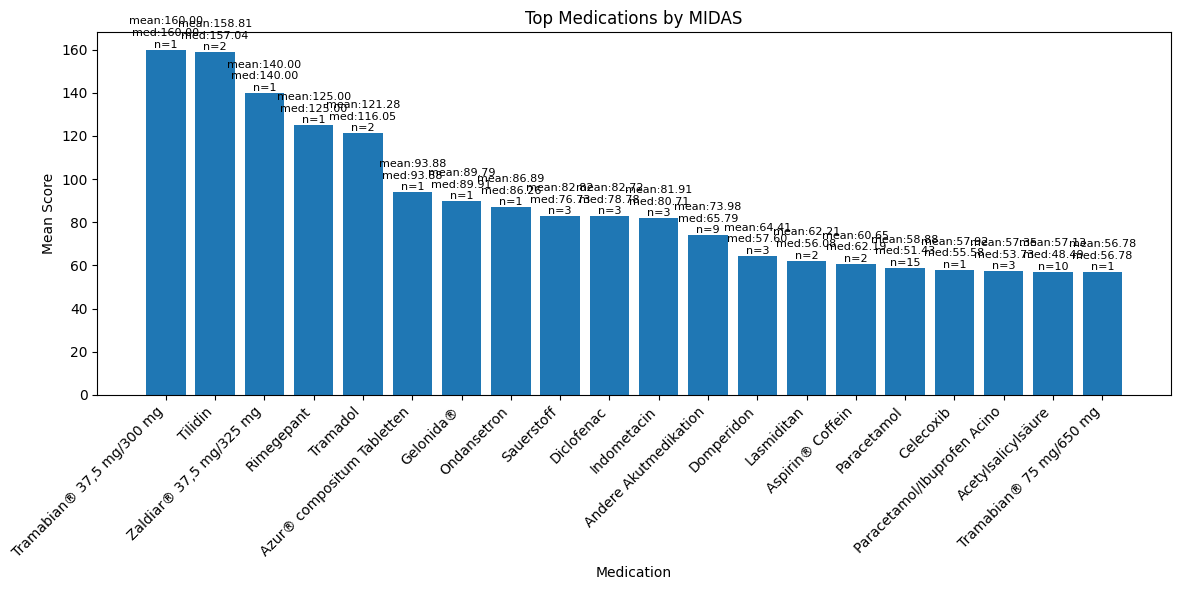

In [16]:
df = results["midas_result"].copy()

# optional: focus on top 20 by mean
top_n = 20
df_plot = df.sort_values("mean", ascending=False).head(top_n)

# make plot (vertical bars instead of horizontal)
plt.figure(figsize=(12, 6))

bars = plt.bar(df_plot.index, df_plot["mean"])

plt.xlabel("Medication")
plt.ylabel("Mean Score")
plt.title("Top Medications by MIDAS")

plt.xticks(rotation=45, ha="right")

# add labels: mean / median / count
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"mean:{row['mean']:.2f}\nmed:{row['median']:.2f}\nn={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [17]:
results["dass_depression"].head(20)

,count,mean,median
medication,,,
Titralgan® gegen Schmerzen,1.000000,13.000000,13.000000
Phenazon,1.250000,10.125000,10.125000
Indometacin,3.235294,7.673174,7.352941
Tramabian® 75 mg/650 mg,1.000000,7.666667,7.666667
Paracetamol/Ibuprofen Acino,3.818182,7.089394,6.954545
Tramadol,2.045455,6.931818,6.727273
Sauerstoff,3.625000,6.920641,6.734375
Tilidin,2.229167,6.790215,6.864583
Diclofenac,3.862069,6.465893,6.068966


In [18]:
results["dass_fear"].head(20)

,count,mean,median
medication,,,
Vivimed® mit Coffein gegen Kopfschmerzen,1.000000,7.000000,7.000000
Paracetamol/Ibuprofen Acino,3.818182,6.741667,6.681818
Migraeflux® MCP,1.111111,6.611111,6.611111
Phenazon,1.250000,6.125000,6.125000
Tilidin,2.229167,6.082449,6.041667
Gelonida®,1.227273,5.924242,5.500000
Tramadol,2.045455,5.888258,5.795455
Lidocain nasal,2.000000,5.500000,5.500000
"Tramabian® 37,5 mg/300 mg",1.000000,4.600000,4.600000


In [19]:
results["dass_stress"].head(20)

,count,mean,median
medication,,,
Titralgan® gegen Schmerzen,1.000000,17.000000,17.000000
Gelonida®,1.227273,12.113636,12.159091
Octadon®,1.250000,11.625000,11.625000
Phenazon,1.250000,10.875000,10.875000
Tilidin,2.229167,10.671843,10.666667
Tramabian® 75 mg/650 mg,1.000000,10.555556,10.555556
Migraeflux® MCP,1.111111,10.277778,10.277778
Paracetamol AL comp.,1.521739,10.137681,10.239130
"Tramabian® 37,5 mg/300 mg",1.000000,9.400000,9.400000


In [20]:
results["gvas_result"].head(20)

,count,mean,median
medication,,,
Dolopyrin®,1.000000,100.000000,100.000000
Para-Caf®,1.000000,100.000000,100.000000
Doppel Spalt®,1.000000,96.333333,96.333333
Suvexx® (Sumatriptan/Naproxen 85mg/500mg),1.000000,80.800000,80.800000
Voltaren® plus,1.000000,71.333333,71.333333
Spalt® Schmerztabletten 300 mg/300 mg,1.600000,67.900000,67.900000
Togal® Kopfschmerz-Brause + Vitamin C,1.000000,67.777778,67.777778
Thomapyrin® Emra,2.333333,67.222222,67.666667
Gelonida®,1.227273,57.219697,56.113636


In [21]:
results["pgic_result"].head(20)

,count,mean,median
medication,,,
Tilidin,1.461538,5.207265,5.166667
Azur® compositum Tabletten,1.000000,5.000000,5.000000
Aspirin® Coffein,1.000000,5.000000,5.000000
"Tramabian® 37,5 mg/300 mg",1.000000,5.000000,5.000000
Talvosilen® 500 mg/20 mg Tabletten,1.000000,5.000000,5.000000
Phenazon,1.000000,5.000000,5.000000
Tramadol,1.235294,4.735294,4.735294
Gelonida®,1.166667,4.666667,4.722222
Sauerstoff,2.107143,4.464711,4.375000


In [22]:
results["chiq_result"].head(20)

,count,mean,median
medication,,,
Indometacin,1.000000,31.000000,31.000000
Dimenhydrinat,1.000000,28.000000,28.000000
Thomapyrin® intensiv,2.200000,27.516667,27.500000
Tramadol,1.000000,27.000000,27.000000
Lasmiditan,1.000000,27.000000,27.000000
Acetylsalicylsäure,1.000000,22.500000,22.500000
Neuralgin® Schmerztabletten,1.000000,19.000000,19.000000
Sauerstoff,3.129032,17.485496,17.516129
Zolmitriptan,3.500000,16.192923,16.285714


In [23]:
DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
data = pd.concat([pd.read_csv(f, sep=";") for f in csv_files], ignore_index=True)

PATIENT_ID = "id_patient"
MED_PREFIX = "Tramabian"

score_bases = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "vr12_msc",
    "vr12_psc",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]


C:\Users\karlw\AppData\Local\Temp\ipykernel_37380\1384420151.py:3: DtypeWarning: Columns (0: ichd3_4_K1, 1: comment_4_K1, 2: adverse2_a5_K1, 3: adverse3_a5_K1, 4: adverse1_a6_K1, 5: adverse2_a6_K1, 6: adverse3_a6_K1, 7: acute_name_a7_K1, 8: dosage_unit_a7_K1, 9: dosage_admin_a7_K1, 10: adverse1_a7_K1, 11: adverse2_a7_K1, 12: adverse3_a7_K1, 13: acute_name_a8_K1, 14: dosage_unit_a8_K1, 15: dosage_admin_a8_K1, 16: adverse1_a8_K1, 17: adverse2_a8_K1, 18: adverse3_a8_K1, 19: acute_name_a9_K1, 20: dosage_unit_a9_K1, 21: dosage_admin_a9_K1, 22: adverse1_a9_K1, 23: acute_name_a10_K1, 24: dosage_unit_a10_K1, 25: dosage_admin_a10_K1, 26: adverse1_a10_K1, 27: adverse2_a10_K1, 28: aborted_good_but_adverse_effect_fa_2_K1, 29: aborted_therapy_break_fa_2_K1, 30: aborted_not_needed_fa_2_K1, 31: aborted_good_but_adverse_effect_fa_3_K1, 32: aborted_therapy_break_fa_3_K1, 33: aborted_not_needed_fa_3_K1, 34: aborted_good_but_adverse_effect_fa_4_K1, 35: aborted_better_fa_4_K1, 36: aborted_therapy_break_fa

In [24]:
med_cols = [c for c in data.columns if c.startswith("acute_name_a")]
dose_cols = [c for c in data.columns if c.startswith("dosage_a")]

print(f"Found {len(med_cols)} medication columns")
print(f"Found {len(dose_cols)} dosage columns")

Found 288 medication columns
Found 1272 dosage columns


In [25]:
records = []

for med_col in med_cols:

    # extract K index safely
    if "_K" not in med_col:
        continue

    k = med_col.split("_K")[-1]
    dose_col = f"dosage_a{k}_K{k}"

    if dose_col not in data.columns:
        continue

    tmp = data[[PATIENT_ID, med_col, dose_col]].copy()

    tmp = tmp.rename(columns={
        med_col: "medication",
        dose_col: "dose"
    })

    # filter medication
    tmp = tmp[tmp["medication"].astype(str).str.startswith(MED_PREFIX, na=False)]

    tmp["dose"] = pd.to_numeric(tmp["dose"], errors="coerce")

    # attach scores (wide → long expansion)
    for score in score_bases:

        # find matching score column for same visit K
        score_col = f"{score}_K{k}"

        if score_col not in data.columns:
            continue

        tmp2 = tmp.copy()
        tmp2["score"] = pd.to_numeric(data.loc[tmp.index, score_col], errors="coerce")

        tmp2 = tmp2.dropna(subset=["dose", "score"])

        for _, row in tmp2.iterrows():
            records.append({
                "patient": row[PATIENT_ID],
                "medication": row["medication"],
                "dose": row["dose"],
                "score_type": score,
                "score": row["score"],
                "visit_k": k
            })

df = pd.DataFrame(records)

print("Final usable rows:", len(df))

Final usable rows: 59


In [26]:
results = []

for score in df["score_type"].unique():

    sub = df[df["score_type"] == score]

    if len(sub) < 3:
        continue

    corr = sub["dose"].corr(sub["score"])

    results.append({
        "score": score,
        "n": len(sub),
        "corr": corr
    })

result_df = pd.DataFrame(results)

if len(result_df) == 0:
    print("No valid correlations.")
else:
    result_df = result_df.sort_values("corr", key=lambda x: x.abs(), ascending=False)

    print("\nTOP CORRELATIONS:")
    print(result_df)


TOP CORRELATIONS:
             score   n      corr
5      pgic_result   9  0.463936
0     midas_result  10  0.424846
1  dass_depression  10  0.139564
2        dass_fear  10 -0.136906
3      dass_stress  10 -0.117555
4      gvas_result  10 -0.016364


In [27]:
pivot = result_df.pivot_table(
    index="score",
    values="corr",
    aggfunc="mean"
).sort_values("corr", ascending=False)

print("\nAVERAGE CORRELATION PER SCORE:")
print(pivot)


AVERAGE CORRELATION PER SCORE:
                     corr
score                    
pgic_result      0.463936
midas_result     0.424846
dass_depression  0.139564
gvas_result     -0.016364
dass_stress     -0.117555
dass_fear       -0.136906
